# 05 - ETF 数据采集

本 Notebook 完成以下任务：
1. ETF 日线行情采集（历史 + 增量）
2. ETF 重仓股持仓采集
3. 数据验证

---

## 设计方案

### ETF 三类数据
| 数据 | 表 | 接口 | 频率 |
|------|-----|------|------|
| 基础信息 | etf_info | fund_basic | 按需（已在 02 中完成） |
| 日线行情 | etf_daily | fund_daily | 每日 |
| 重仓股持仓 | etf_holding | fund_portfolio | 季度 |

### 增量机制
ETF 日线同样使用交易日历比对实现增量更新。

## 1. ETF 日线历史采集

In [1]:
from invest_model.db import get_engine
from invest_model.sources.tushare_client import TushareClient
from invest_model.collectors.etf_collector import ETFCollector
from invest_model.repositories.stock_pool_repo import StockPoolRepository

engine = get_engine()
ts_client = TushareClient()

pool_repo = StockPoolRepository(engine)
etf_codes = pool_repo.get_pool_codes("etf")
print(f"待采集 ETF: {etf_codes}")

collector = ETFCollector(ts_client, engine)
results = collector.collect_daily_history(etf_codes)

for code, count in results.items():
    print(f"  {code}: {count} 条")

17:23:35 | INFO    | Tushare 客户端初始化完成


待采集 ETF: ['159915.SZ', '510300.SH', '510500.SH']


17:23:36 | INFO    | ETF 159915.SZ: 写入 1210 条日线


17:23:36 | INFO    | ETF 510300.SH: 写入 1210 条日线


17:23:37 | INFO    | ETF 510500.SH: 写入 1210 条日线


  159915.SZ: 1210 条
  510300.SH: 1210 条
  510500.SH: 1210 条


## 2. ETF 重仓股持仓

In [2]:
n = collector.collect_holdings(etf_codes)
print(f"ETF 持仓采集完成: {n} 条")

17:24:33 | INFO    | ETF 持仓采集完成: 232581 条


ETF 持仓采集完成: 232581 条


## 3. 数据验证

In [3]:
from invest_model.repositories.etf_repo import ETFRepository

etf_repo = ETFRepository(engine)

# 查看沪深300ETF 日线
df = etf_repo.get_daily("510300.SH", "20260301", "20260406")
print(f"510300.SH 近期日线 ({len(df)} 条):")
print(df.tail(10).to_string(index=False))

510300.SH 近期日线 (25 条):
     code trade_date  open  high   low  close  pre_close  change  pct_chg volume      amount          created_at
510300.SH   20260323 4.528 4.537 4.406  4.430      4.576  -0.146  -3.1906   None 6799292.790 2026-04-07 17:23:36
510300.SH   20260324 4.463 4.480 4.405  4.479      4.430   0.049   1.1061   None 3784113.263 2026-04-07 17:23:36
510300.SH   20260325 4.510 4.549 4.504  4.544      4.479   0.065   1.4512   None 3932266.869 2026-04-07 17:23:36
510300.SH   20260326 4.536 4.547 4.477  4.488      4.544  -0.056  -1.2324   None 2139118.213 2026-04-07 17:23:36
510300.SH   20260327 4.450 4.530 4.445  4.508      4.488   0.020   0.4456   None 2529639.239 2026-04-07 17:23:36
510300.SH   20260330 4.462 4.505 4.453  4.500      4.508  -0.008  -0.1775   None 2434696.108 2026-04-07 17:23:36
510300.SH   20260331 4.501 4.529 4.462  4.463      4.500  -0.037  -0.8222   None 2385310.576 2026-04-07 17:23:36
510300.SH   20260401 4.520 4.542 4.501  4.534      4.463   0.071   1.5909

In [4]:
# 查看 ETF 持仓
holding = etf_repo.get_holding("510300.SH")
if not holding.empty:
    print(f"510300.SH 持仓 ({len(holding)} 条):")
    print(holding.head(10).to_string(index=False))
else:
    print("暂无持仓数据")

510300.SH 持仓 (15993 条):
    id      code report_date stock_code stock_name  holding_amount   holding_mv  holding_ratio          created_at
128919 510300.SH    20261231  601318.SH       None      13942627.0 576388200.18           3.51 2026-04-07 17:24:09
128923 510300.SH    20261231  600036.SH       None      48036517.0 499099411.63           3.04 2026-04-07 17:24:09
128836 510300.SH    20261231  600016.SH       None      79173699.0 494043881.76           3.01 2026-04-07 17:24:09
128920 510300.SH    20261231  601166.SH       None      33288708.0 340210595.76           2.07 2026-04-07 17:24:09
128876 510300.SH    20261231  600000.SH       None      32439759.0 316287650.25           1.93 2026-04-07 17:24:09
128894 510300.SH    20261231  600030.SH       None      27605100.0 316354446.00           1.80 2026-04-07 17:24:09
129123 510300.SH    20261231  600837.SH       None      25492081.0 263078275.92           1.60 2026-04-07 17:24:09
128700 510300.SH    20261231  000002.SZ       None      

## 4.1 510300 净值走势

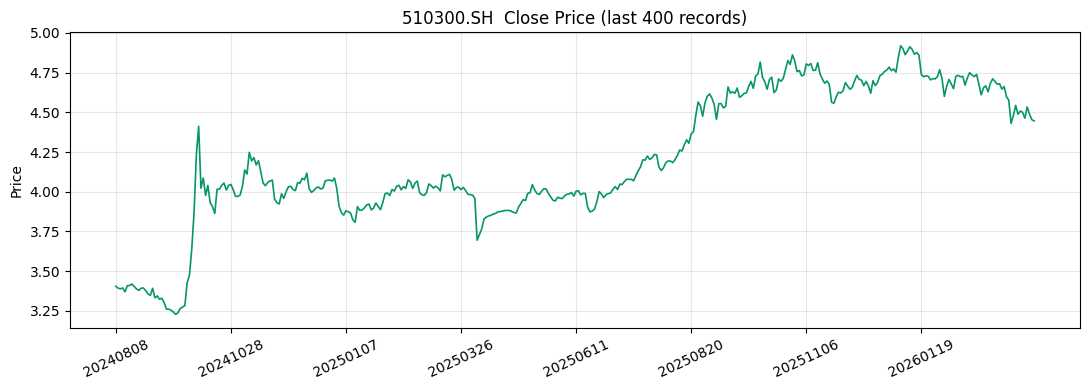

In [5]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
from invest_model.repositories.etf_repo import ETFRepository

etf_repo2 = ETFRepository(engine)
edf = etf_repo2.get_daily("510300.SH", "20200101", "20991231")
if edf.empty:
    print("No ETF data, skip chart")
else:
    edf = edf.dropna(subset=["close"]).tail(400).reset_index(drop=True)
    x = range(len(edf))
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(x, edf["close"], color="#059669", linewidth=1.2)
    ax.set_title("510300.SH  Close Price (last 400 records)")
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.3)
    step = max(1, len(edf) // 8)
    ax.set_xticks(list(x)[::step])
    ax.set_xticklabels(edf["trade_date"].astype(str).iloc[::step], rotation=25)
    plt.tight_layout()
    plt.show()

## 完成

ETF 数据采集完毕，继续 `06_events.ipynb` 采集事件数据。